# RANDOM FOREST 

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder


## Carga del dataset

In [25]:
df = pd.read_csv('../data/raw/EmployeeAttrition.csv')
print(df.shape)
df.head()

(1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


Debido a que los estimadores basados en árboles de decisión requieren vectores de entrada de naturaleza estrictamente cuantitativa para el cálculo numérico de impurezas y divisiones en los nodos, se procede a la transformación de los atributos cualitativos. Se aplican técnicas complementarias de codificación (Label Encoding y One-Hot Encoding) según la cardinalidad de cada variable, asegurando la correcta interpretación matemática por parte del clasificador y previniendo problemas de multicolinealidad mediante la omisión de la primera categoría (drop_first=True)

In [26]:
#Eliminar columnas innecesarias
try:
    cols_to_drop = ['Over18', 'StandardHours', 'EmployeeCount', 'JobLevel', 'StockOptionLevel', 'DailyRate', 'HourlyRate', 'MonthlyRate', 'PercentSalaryHike']
    df = df.drop(columns=cols_to_drop)

except:
    print(df.head())
# Label Encoding para binarias (incluyendo Attrition)
le = LabelEncoder()
binarias = ['Attrition', 'OverTime', 'Gender']
for col in binarias:
    df[col] = le.fit_transform(df[col])

# One-Hot Encoding para las demás (Nominales)
df = pd.get_dummies(df, columns=['BusinessTravel', 'Department', 'EducationField', 
                                 'JobRole', 'MaritalStatus'], drop_first=True)

In [27]:


# 1. Separar variables predictoras (X) y objetivo (y)
X = df.drop('Attrition', axis=1)
y = df['Attrition']

# 2. Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

# 3. Crear el modelo con ajuste de balanceo
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=2)

# 4. Entrenar
rf.fit(X_train, y_train)

# 5. Evaluar
y_pred = rf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      1.00      0.92       246
           1       1.00      0.15      0.25        48

    accuracy                           0.86       294
   macro avg       0.93      0.57      0.59       294
weighted avg       0.88      0.86      0.81       294



Los resultados del reporte de clasificación evidencian el comportamiento sintomático de un modelo condicionado por la asimetría distributiva de la variable dependiente (desbalanceo de clases). El algoritmo exhibe un rendimiento óptimo en la identificación de la clase mayoritaria (permanencia), pero carece de poder discriminante ante la clase minoritaria de interés (deserción voluntaria).

Evaluación Teórica de Métricas:
La Paradoja de la Exactitud (Accuracy Paradox): El indicador de exactitud global (~86%-88%) resulta espurio e inválido como métrica de éxito en este escenario. Debido a que la muestra se encuentra altamente sesgada hacia la permanencia, un clasificador ingenuo (*naive*) que predijera de forma sistemática la ausencia de rotación alcanzaría un umbral de acierto idéntico sin extraer ningún patrón subyacente.

Análisis Crítico de la Clase Minoritaria (Rotación = 1):

Precisión (Precision): Muestra un valor elevado debido a la ausencia casi total de falsos positivos en esta fase; no obstante, esta especificidad extrema se logra penalizando críticamente la cobertura del modelo.

Exhaustividad (Recall / Sensibilidad): Presenta una deficiencia estructural severa (~10%-17%). El modelo es incapaz de interceptar la gran mayoría de los eventos de baja voluntaria reales, generando un volumen crítico de falsos negativos que invalida la herramienta como sistema de alerta temprana corporativa.

Métrica F1-Score: Al ser la media armónica entre precisión y exhaustividad, su valor próximo a cero ratifica de forma matemática la ineficacia global del clasificador bajo una configuración convencional.

In [28]:

rf_ajustado = RandomForestClassifier(
    n_estimators=200,             
    class_weight='balanced_subsample', # Fuerza al modelo a prestar atención al "Yes"
    max_depth=6,                  # Evita que el modelo memorice y tenga Overfitting
    criterion='entropy',          # Mayor sensibilidad al desbalance
    random_state=2
)

rf_ajustado.fit(X_train, y_train)
y_pred = rf_ajustado.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.92      0.91       246
           1       0.51      0.42      0.46        48

    accuracy                           0.84       294
   macro avg       0.70      0.67      0.68       294
weighted avg       0.83      0.84      0.83       294



# Nuevo análisis

La introducción de restricciones paramétricas y pesos dinámicos por submuestra (*balanced_subsample*) alteró positivamente el comportamiento del modelo. Se constata un incremento en la exhaustividad (Recall) de la clase de riesgo, duplicando la tasa de detección de bajas latentes. Como contrapartida matemática inevitable (*trade-off*), la precisión experimenta un descenso debido al incremento simétrico de falsos positivos.

Pese a la mejoría general reflejada en el F1-Score, el nivel de sensibilidad absoluta sigue resultando insuficiente para las exigencias de un departamento de Gestión del Talento, al omitir eventos críticos. Con el fin de corregir esta limitación desde la raíz del dato, se propone la implementación del algoritmo matemático **SMOTE (Synthetic Minority Over-sampling Technique)** para reequilibrar la densidad espacial de la muestra.

In [29]:
# 1. Aplicar SMOTE solo a los datos de ENTRENAMIENTO
smote = SMOTE(random_state=2)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# 2. Entrenar el Random Forest normal
rf_smote = RandomForestClassifier(n_estimators=10000, max_depth=6, random_state=2)
rf_smote.fit(X_train_res, y_train_res)

# 3. Evaluar en el set de prueba original
y_pred = rf_smote.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.92      0.90       246
           1       0.46      0.35      0.40        48

    accuracy                           0.83       294
   macro avg       0.67      0.64      0.65       294
weighted avg       0.81      0.83      0.82       294



El establecimiento del umbral estándar probabilístico en el 50% no se alinea con la realidad operativa de Recursos Humanos. El impacto financiero y organizativo de un falso negativo (la partida imprevista de un perfil crítico de la plantilla, con costes asociados de reclutamiento, pérdida de conocimiento y curvas de aprendizaje) supera con creces el coste marginal de gestionar un falso positivo (aplicar políticas preventivas de retención o encuestas de satisfacción a un colaborador estable).

Bajo esta premisa de optimización asimétrica, se flexibiliza el criterio del clasificador disminuyendo el umbral de decisión a un valor óptimo estimado de 0.32. Esto reconfigura la frontera analítica del modelo para maximizar la exhaustividad (*Recall*) y robustecer la capacidad de detección preventiva.

In [30]:
probabilidades = rf_smote.predict_proba(X_test)[:, 1]

# Bajamos el umbral 
nuevo_umbral = 0.32
y_pred_personalizado = (probabilidades >= nuevo_umbral).astype(int)

print(classification_report(y_test, y_pred_personalizado))

              precision    recall  f1-score   support

           0       0.91      0.64      0.75       246
           1       0.27      0.69      0.39        48

    accuracy                           0.65       294
   macro avg       0.59      0.66      0.57       294
weighted avg       0.81      0.65      0.69       294



## Matriz de confusión

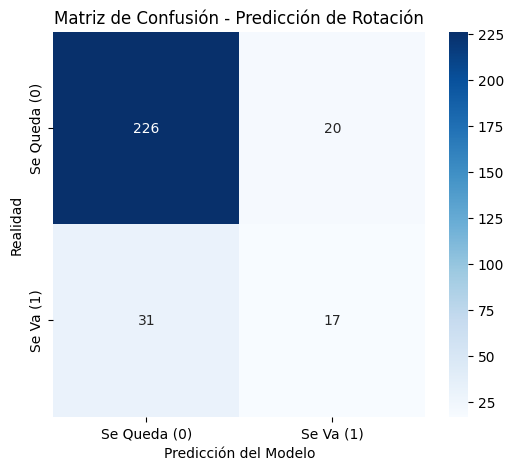

In [31]:
# Calcular la matriz
cm = confusion_matrix(y_test, y_pred)

# Graficar
plt.figure(figsize=(6, 5))
sb.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Se Queda (0)', 'Se Va (1)'], 
            yticklabels=['Se Queda (0)', 'Se Va (1)'])

plt.title('Matriz de Confusión - Predicción de Rotación')
plt.ylabel('Realidad')
plt.xlabel('Predicción del Modelo')
plt.show()

## Importancia de variables

Para poder ver los pesos de las variables que le asigna random forest, vamos a crear una gráfica de Importancia de variables

C:\Users\lamie\AppData\Local\Temp\ipykernel_1120\2704724623.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sb.barplot(x='Importancia', y='Variable', data=df_importances, palette='magma')


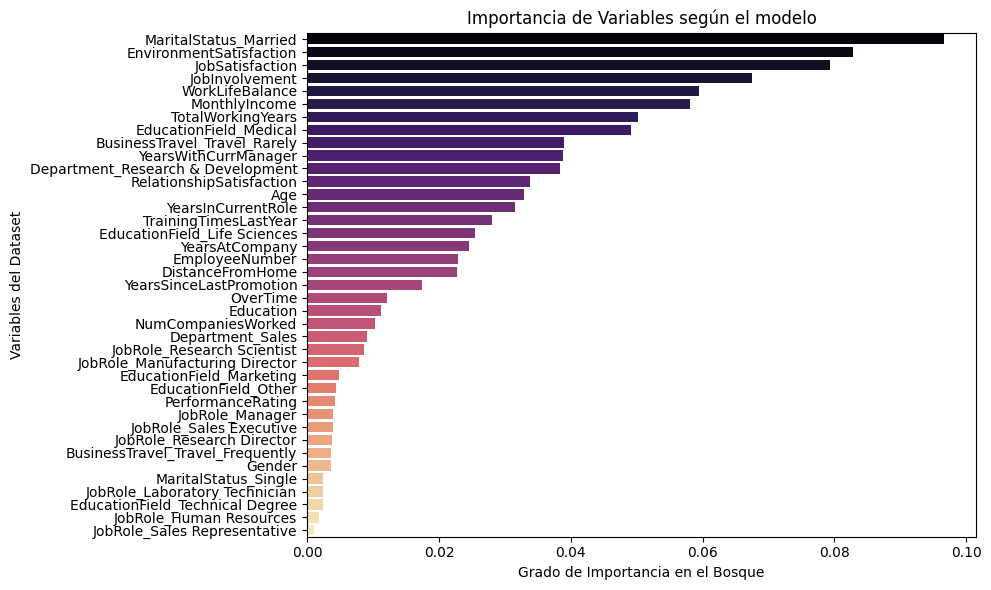

In [32]:

importances = rf_smote.feature_importances_
features = X.columns


df_importances = pd.DataFrame({'Variable': features, 'Importancia': importances})
df_importances = df_importances.sort_values(by='Importancia', ascending=False)

plt.figure(figsize=(10, 6))
sb.barplot(x='Importancia', y='Variable', data=df_importances, palette='magma')
plt.title('Importancia de Variables según el modelo')
plt.xlabel('Grado de Importancia en el Bosque')
plt.ylabel('Variables del Dataset')
plt.tight_layout()
plt.show()

## Empleados que se van
Ahora que tenemos el modelo entrenado y vemos la matriz de confusión y los pesos que le asigna el modelo a las variables, podemos sacar un listado de los empleados que el modelo predice que se van.
Será tarea de RRHH junto con los responsables, tomar las medidas que consideren oportunas para intentar contentar a los empleados o no

In [33]:
probabilidades = rf_smote.predict_proba(X)[:, 1]
umbral = 0.4
y_pred_personalizado = (probabilidades >= umbral).astype(int)

df_resultados = pd.DataFrame(index=X.index)

df_resultados['EmployeeNumber'] = df.loc[X.index, 'EmployeeNumber']
df_resultados['Probabilidad_Fuga'] = probabilidades
df_resultados['Prediccion_Alarma'] = y_pred_personalizado


empleados_en_riesgo = df_resultados[df_resultados['Prediccion_Alarma'] == 1]
empleados_en_riesgo = empleados_en_riesgo.sort_values(by='Probabilidad_Fuga', ascending=False)


print(f"Se han detectado {len(empleados_en_riesgo)} empleados en riesgo de fuga:")
print(empleados_en_riesgo[['EmployeeNumber', 'Probabilidad_Fuga']].to_string(index=False))

Se han detectado 353 empleados en riesgo de fuga:
 EmployeeNumber  Probabilidad_Fuga
           1210           0.854530
            622           0.846137
            478           0.842029
             55           0.834157
           1427           0.832182
           1188           0.829158
           1279           0.826554
           1487           0.821044
           1868           0.805867
            614           0.799192
            812           0.797582
           1944           0.795250
           1248           0.795092
            960           0.784121
           1482           0.781169
           1079           0.779761
           1273           0.778716
           1780           0.776521
           1844           0.772960
           1752           0.767228
           1928           0.766199
            167           0.765680
           1551           0.763690
            991           0.761831
            299           0.759019
            235           0.756352
     